# Compare KDE and ZIG calcium likelihoods

This notebook validates the new ZIG calcium likelihood against the existing KDE spike likelihood on the same simulated calcium pipeline.

Planned flow:
1. Simulate run and replay datasets.
2. Deconvolve calcium traces once with OASIS.
3. Decode with KDE and ZIG likelihoods.
4. Compare posteriors and decoding error.

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr

from oasis.functions import deconvolve

from replay_trajectory_classification.calcium_sorted_spikes_decoding import (
    make_sorted_spikes_decoder,
    maximum_a_posteriori_position,
    median_decoding_error,
)
from replay_trajectory_classification.core import (
    _acausal_decode,
    _causal_decode,
    scaled_likelihood,
)
from replay_trajectory_classification.likelihoods.deconv_calcium_likelihood import (
    estimate_zig_likelihood,
    estimate_zig_place_fields,
)
from replay_trajectory_classification.likelihoods.spiking_likelihood_kde import (
    estimate_spiking_likelihood_kde,
)
from replay_trajectory_classification.simulate import simulate_position, simulate_time
from replay_trajectory_classification.simulate_calcium import (
    make_continuous_replay,
    make_simulated_run_data,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_context("talk", font_scale=0.8)
np.random.seed(0)

In [17]:
TRACK_HEIGHT = 200.0
N_NEURONS = 20
PLACE_FIELD_MEANS = np.linspace(0.0, TRACK_HEIGHT, N_NEURONS)
RUN_SAMPLING_FREQUENCY = 30
REPLAY_SAMPLING_FREQUENCY = 200
INTERNAL_SAMPLING_FREQUENCY = 1000
N_RUNS = 2
BASE_SIGMA = 5.0
BASE_RUNNING_SPEED = 10.0
REPLAY_SPEEDUP = 120
POSITION_STD = 3.0
ZIG_N_EPOCHS = 2000

In [18]:
def deconvolve_oasis(calcium_traces):
    calcium_traces = np.asarray(calcium_traces, dtype=float)
    if calcium_traces.ndim == 1:
        calcium_traces = calcium_traces[:, np.newaxis]

    n_time, n_neurons = calcium_traces.shape
    shift = max(1, min(100, n_time // 2))
    s_continuous = np.zeros((n_time, n_neurons), dtype=float)

    for neuron_ind in range(n_neurons):
        _, spikes, _, _, _ = deconvolve(
            calcium_traces[:, neuron_ind],
            g=(None, None),
            penalty=1,
            shift=shift,
        )
        s_continuous[:, neuron_ind] = np.asarray(spikes, dtype=float)

    s_binary = (s_continuous > 0).astype(np.int8)
    return s_continuous, s_binary


def make_true_continuous_replay_position(
    sampling_frequency=REPLAY_SAMPLING_FREQUENCY,
    internal_sampling_frequency=INTERNAL_SAMPLING_FREQUENCY,
    track_height=TRACK_HEIGHT,
    running_speed=BASE_RUNNING_SPEED,
    replay_speedup=REPLAY_SPEEDUP,
    is_outbound=True,
):
    replay_speed = running_speed * replay_speedup
    n_samples = int(np.ceil(2 * internal_sampling_frequency * track_height / replay_speed))
    replay_time_internal = simulate_time(n_samples, internal_sampling_frequency)
    replay_position_internal = simulate_position(replay_time_internal, track_height, replay_speed)
    half_n_samples = n_samples // 2
    if is_outbound:
        replay_position_internal = replay_position_internal[:half_n_samples]
    else:
        replay_position_internal = replay_position_internal[-half_n_samples:]
    subsample_factor = internal_sampling_frequency // sampling_frequency
    return replay_position_internal[::subsample_factor]


def make_run_dataset(rng_seed, sigma=BASE_SIGMA, running_speed=BASE_RUNNING_SPEED):
    time, position, sampling_frequency, calcium_traces, true_spikes, place_fields = make_simulated_run_data(
        sampling_frequency=RUN_SAMPLING_FREQUENCY,
        track_height=TRACK_HEIGHT,
        running_speed=running_speed,
        n_runs=N_RUNS,
        place_field_means=PLACE_FIELD_MEANS,
        sigma=sigma,
        rng=np.random.default_rng(rng_seed),
    )
    s_continuous, s_binary = deconvolve_oasis(calcium_traces)
    return {
        "time": time,
        "position": position,
        "sampling_frequency": sampling_frequency,
        "calcium_traces": calcium_traces,
        "true_spikes": true_spikes,
        "place_fields": place_fields,
        "s_continuous": s_continuous,
        "s_binary": s_binary,
        "sigma": sigma,
        "running_speed": running_speed,
    }


def make_replay_dataset(rng_seed, sigma=BASE_SIGMA, running_speed=BASE_RUNNING_SPEED):
    time, true_spikes, calcium_traces = make_continuous_replay(
        sampling_frequency=REPLAY_SAMPLING_FREQUENCY,
        internal_sampling_frequency=INTERNAL_SAMPLING_FREQUENCY,
        track_height=TRACK_HEIGHT,
        running_speed=running_speed,
        place_field_means=PLACE_FIELD_MEANS,
        replay_speedup=REPLAY_SPEEDUP,
        sigma=sigma,
        rng=np.random.default_rng(rng_seed),
    )
    true_position = make_true_continuous_replay_position(running_speed=running_speed)[: len(time)]
    s_continuous, s_binary = deconvolve_oasis(calcium_traces)
    return {
        "time": time,
        "position": true_position,
        "sampling_frequency": REPLAY_SAMPLING_FREQUENCY,
        "calcium_traces": calcium_traces,
        "true_spikes": true_spikes,
        "s_continuous": s_continuous,
        "s_binary": s_binary,
        "sigma": sigma,
        "running_speed": running_speed,
    }


def fit_shared_decoder(train_dataset):
    decoder = make_sorted_spikes_decoder(
        position=train_dataset["position"],
        sampling_frequency=train_dataset["sampling_frequency"],
        position_std=POSITION_STD,
    )
    decoder.fit(train_dataset["position"], train_dataset["s_binary"])
    return decoder


def build_posteriors(log_likelihood, decoder, time):
    time = np.asarray(time)
    is_track_interior = decoder.environment.is_track_interior_.ravel(order="F")
    n_time = time.shape[0]
    n_position_bins = is_track_interior.shape[0]
    st_interior_ind = np.ix_(is_track_interior, is_track_interior)
    likelihood = scaled_likelihood(np.asarray(log_likelihood, dtype=float))

    causal_posterior = np.full((n_time, n_position_bins), np.nan, dtype=float)
    causal_posterior[:, is_track_interior], data_log_likelihood = _causal_decode(
        decoder.initial_conditions_[is_track_interior].astype(float),
        decoder.state_transition_[st_interior_ind].astype(float),
        likelihood[:, is_track_interior].astype(float),
    )

    acausal_posterior = np.full((n_time, n_position_bins, 1), np.nan, dtype=float)
    acausal_posterior[:, is_track_interior] = _acausal_decode(
        causal_posterior[:, is_track_interior, np.newaxis].astype(float),
        decoder.state_transition_[st_interior_ind].astype(float),
    )

    position = decoder.environment.place_bin_centers_.squeeze()
    return {
        "likelihood": xr.DataArray(likelihood, coords={"time": time, "position": position}, dims=["time", "position"]),
        "causal_posterior": xr.DataArray(causal_posterior, coords={"time": time, "position": position}, dims=["time", "position"]),
        "acausal_posterior": xr.DataArray(acausal_posterior.squeeze(-1), coords={"time": time, "position": position}, dims=["time", "position"]),
        "data_log_likelihood": float(data_log_likelihood),
    }

## Shared deconvolution check

In [19]:
run_a = make_run_dataset(rng_seed=0)
run_b = make_run_dataset(rng_seed=1)
replay_b = make_replay_dataset(rng_seed=2)

pd.DataFrame(
    [
        {
            "dataset": "run_a",
            "n_time": len(run_a["time"]),
            "s_continuous_shape": run_a["s_continuous"].shape,
            "s_binary_shape": run_a["s_binary"].shape,
            "binary_spike_fraction": float(run_a["s_binary"].mean()),
        },
        {
            "dataset": "run_b",
            "n_time": len(run_b["time"]),
            "s_continuous_shape": run_b["s_continuous"].shape,
            "s_binary_shape": run_b["s_binary"].shape,
            "binary_spike_fraction": float(run_b["s_binary"].mean()),
        },
        {
            "dataset": "replay_b",
            "n_time": len(replay_b["time"]),
            "s_continuous_shape": replay_b["s_continuous"].shape,
            "s_binary_shape": replay_b["s_binary"].shape,
            "binary_spike_fraction": float(replay_b["s_binary"].mean()),
        },
    ]
)

/home/ericliu/anaconda3/lib/python3.13/site-packages/oasis/functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arange(lags)],
/home/ericliu/anaconda3/lib/python3.13/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 200, using nperseg = 200
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


,dataset,n_time,s_continuous_shape,s_binary_shape,binary_spike_fraction
0,run_a,2424,"(2424, 20)","(2424, 20)",0.014336
1,run_b,2424,"(2424, 20)","(2424, 20)",0.014233
2,replay_b,200,"(200, 20)","(200, 20)",0.088750


## KDE path

In [20]:
def decode_with_kde(decoder, dataset):
    log_likelihood = estimate_spiking_likelihood_kde(
        dataset["s_binary"],
        np.asarray(decoder.place_fields_),
        is_track_interior=decoder.environment.is_track_interior_,
    )
    return build_posteriors(log_likelihood, decoder, dataset["time"])


shared_decoder = fit_shared_decoder(run_a)
kde_run_b_results = decode_with_kde(shared_decoder, run_b)
kde_replay_b_results = decode_with_kde(shared_decoder, replay_b)

kde_summary = pd.DataFrame(
    [
        {
            "dataset": "run_b",
            "median_abs_error": median_decoding_error(kde_run_b_results["acausal_posterior"], run_b["position"]),
            "data_log_likelihood": kde_run_b_results["data_log_likelihood"],
        },
        {
            "dataset": "replay_b",
            "median_abs_error": median_decoding_error(kde_replay_b_results["acausal_posterior"], replay_b["position"]),
            "data_log_likelihood": kde_replay_b_results["data_log_likelihood"],
        },
    ]
)
kde_summary

/home/ericliu/anaconda3/lib/python3.13/site-packages/replay_trajectory_classification/likelihoods/spiking_likelihood_kde.py:148: RuntimeWarning: divide by zero encountered in log
  return np.exp(np.log(mean_rate) + np.log(marginal_density) - np.log(occupancy))


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

ValueError: operands could not be broadcast together with shapes (200,) (34,) 

## ZIG path

In [ ]:
zig_place_fields, zig_k_values = estimate_zig_place_fields(
    run_a["position"],
    run_a["s_continuous"],
    place_bin_centers=shared_decoder.environment.place_bin_centers_,
    place_bin_edges=shared_decoder.environment.place_bin_edges_,
    n_epochs=ZIG_N_EPOCHS,
)

def decode_with_zig(decoder, dataset, zig_place_fields, zig_k_values):
    log_likelihood = estimate_zig_likelihood(
        dataset["s_continuous"],
        zig_place_fields,
        zig_k_values,
        is_track_interior=decoder.environment.is_track_interior_,
    )
    return build_posteriors(log_likelihood, decoder, dataset["time"])


zig_run_b_results = decode_with_zig(shared_decoder, run_b, zig_place_fields, zig_k_values)
zig_replay_b_results = decode_with_zig(shared_decoder, replay_b, zig_place_fields, zig_k_values)

zig_summary = pd.DataFrame(
    [
        {
            "dataset": "run_b",
            "median_abs_error": median_decoding_error(zig_run_b_results["acausal_posterior"], run_b["position"]),
            "data_log_likelihood": zig_run_b_results["data_log_likelihood"],
        },
        {
            "dataset": "replay_b",
            "median_abs_error": median_decoding_error(zig_replay_b_results["acausal_posterior"], replay_b["position"]),
            "data_log_likelihood": zig_replay_b_results["data_log_likelihood"],
        },
    ]
)
zig_summary

W0000 00:00:1778644794.605901  998079 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1778644794.653507  997258 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
I0000 00:00:1778644794.733263  997258 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


,dataset,median_abs_error,data_log_likelihood
0,run_b,2.563538,-1039.317758
1,replay_b,58.556195,-154.370505


## Comparison figures and summary

In [ ]:
def plot_posterior_panel(ax, dataset, results, title):
    results["acausal_posterior"].plot(
        x="time",
        y="position",
        ax=ax,
        cmap="bone_r",
        add_colorbar=False,
    )
    ax.plot(dataset["time"], dataset["position"], color="magenta", linestyle="--", linewidth=2, label="True")
    ax.plot(
        dataset["time"],
        maximum_a_posteriori_position(results["acausal_posterior"]),
        color="cyan",
        linewidth=1.5,
        alpha=0.9,
        label="MAP",
    )
    ax.set_title(title)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Position")


comparison_summary = pd.concat(
    [kde_summary.assign(method="KDE"), zig_summary.assign(method="ZIG")],
    ignore_index=True,
)[["method", "dataset", "median_abs_error", "data_log_likelihood"]]
comparison_summary

,method,dataset,median_abs_error,data_log_likelihood
0,KDE,run_b,3.421743,-2288.857092
1,KDE,replay_b,21.708061,-455.833742
2,ZIG,run_b,2.563538,-1039.317758
3,ZIG,replay_b,58.556195,-154.370505


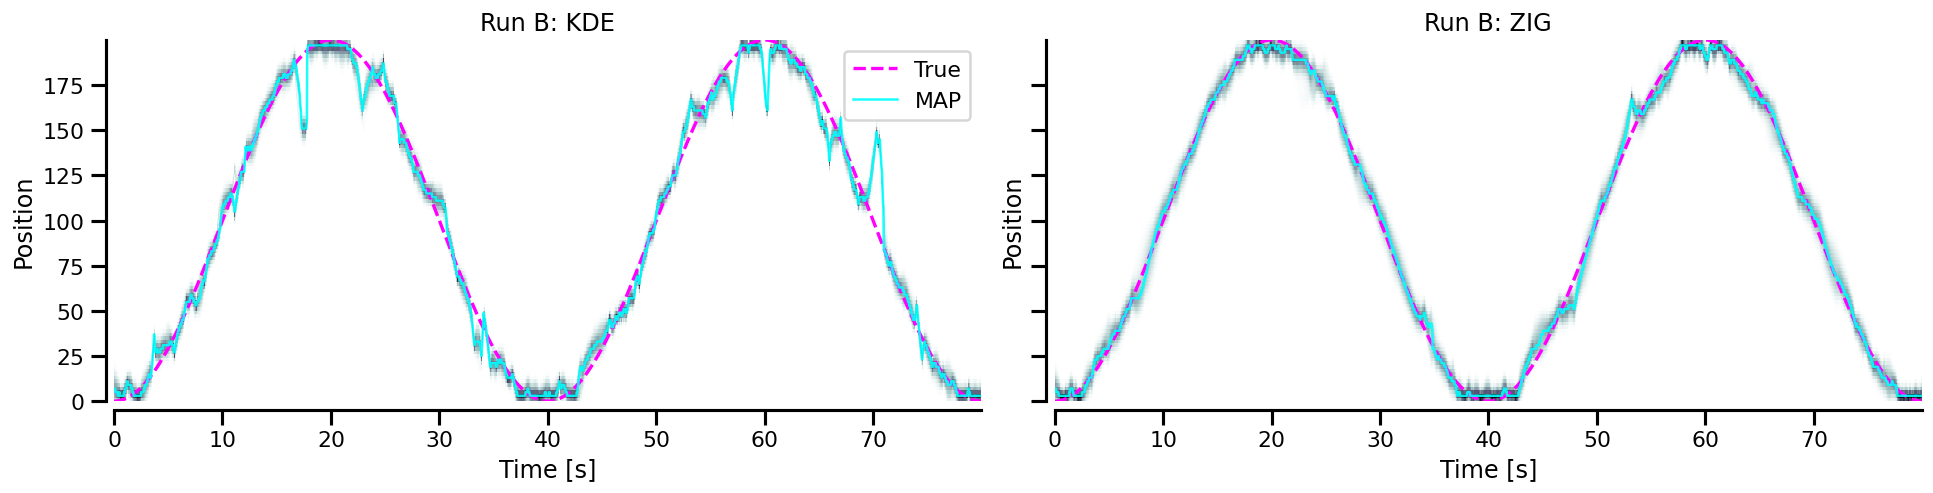

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True, constrained_layout=True)
plot_posterior_panel(axes[0], run_b, kde_run_b_results, "Run B: KDE")
plot_posterior_panel(axes[1], run_b, zig_run_b_results, "Run B: ZIG")
axes[0].legend(loc="upper right")
sns.despine(offset=5)

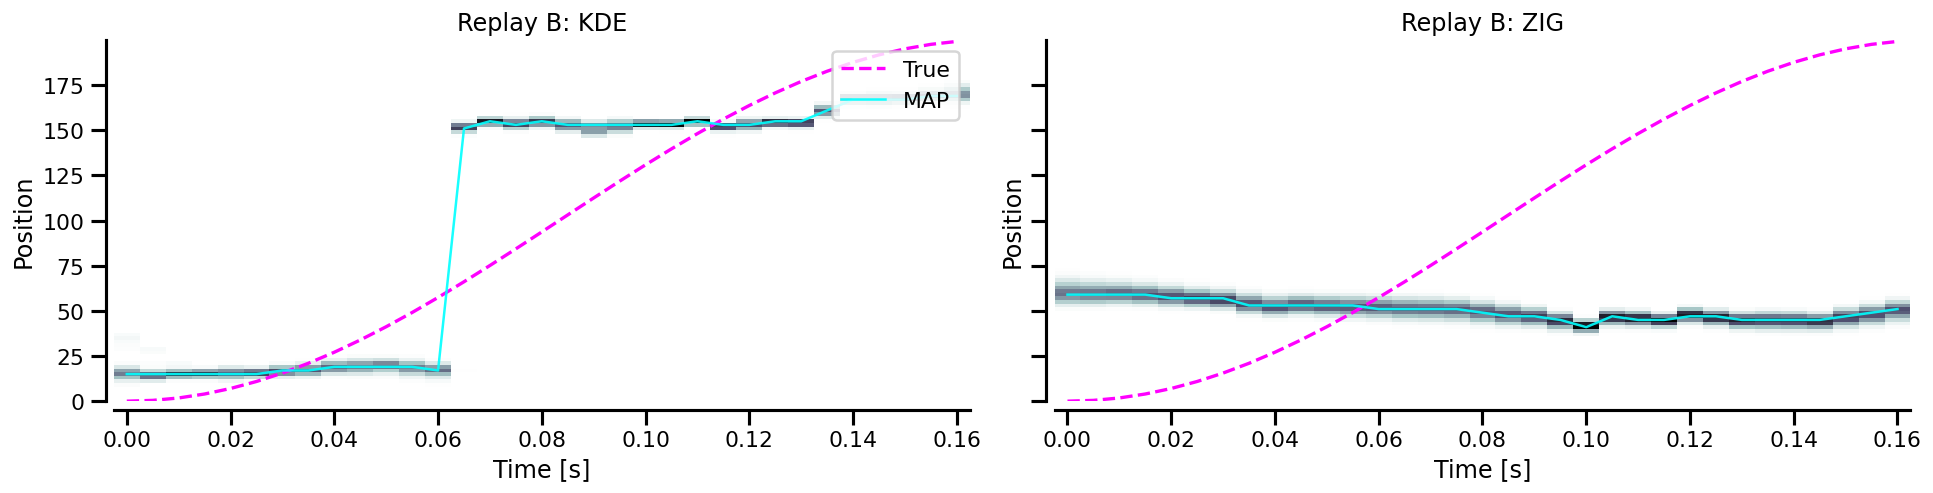

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True, constrained_layout=True)
plot_posterior_panel(axes[0], replay_b, kde_replay_b_results, "Replay B: KDE")
plot_posterior_panel(axes[1], replay_b, zig_replay_b_results, "Replay B: ZIG")
axes[0].legend(loc="upper right")
sns.despine(offset=5)